# 1.调用API

https://oxpzcwcjtbk.feishu.cn/wiki/LXEDwqFUFilhFkklJg7c3qdmnbx

In [13]:
from openai import OpenAI
import os

api_para={
    "ali":{
        "api_key":"",
        "base_url":"https://dashscope.aliyuncs.com/compatible-mode/v1",
        "model_name":"deepseek-r1"
    },
    "silicon":{
        "api_key":"输出你的api_key",
        "base_url":"https://api.siliconflow.cn/v1",
        "model_name":"Pro/deepseek-ai/DeepSeek-R1"
    },
    "baidu":{
        "api_key":"输出你的api_key",
        "base_url":"https://qianfan.baidubce.com/v2",
        "model_name":"deepseek-r1"
    },
    "huoshan":{
        "api_key":"输出你的api_key",
        "base_url":"https://ark.cn-beijing.volces.com/api/v3",
        "model_name":"ep-20250219090715-xsthv"
    },
    "tengxunyun":{
        "api_key":"输出你的api_key",
        "base_url":"https://api.lkeap.cloud.tencent.com/v1",
        "model_name":"deepseek-r1"
    },
}

def deepseek_stream(prompt,api_key,base_url,model_name):
    # 初始化OpenAI客户端
    client = OpenAI(
    # 如果没有配置环境变量，请用API Key替换：api_key="sk-xxx"
    api_key=api_key,
    base_url=base_url,
    )
    
    
    reasoning_content = ""  # 定义完整思考过程
    answer_content = ""     # 定义完整回复
    is_answering = False   # 判断是否结束思考过程并开始回复

    # 创建聊天完成请求
    stream = client.chat.completions.create(
        model=model_name,  # 此处以 deepseek-v3 为例，可按需更换模型名称
        messages=[
            {"role": "user", "content": prompt}
        ],
        stream=True
        # 解除以下注释会在最后一个chunk返回Token使用量
        # stream_options={
        #     "include_usage": True
        # }
    )

    print("\n" + "=" * 20 + "思考过程" + "=" * 20 + "\n")

    for chunk in stream:
        # 处理usage信息
        if not getattr(chunk, 'choices', None):
            print("\n" + "=" * 20 + "Token 使用情况" + "=" * 20 + "\n")
            print(chunk.usage)
            continue

        delta = chunk.choices[0].delta

        # 检查是否有reasoning_content属性
        if not hasattr(delta, 'reasoning_content'):
            continue

        # 处理空内容情况
        if not getattr(delta, 'reasoning_content', None) and not getattr(delta, 'content', None):
            continue

        # 处理开始回答的情况
        if not getattr(delta, 'reasoning_content', None) and not is_answering:
            print("\n" + "=" * 20 + "完整回复" + "=" * 20 + "\n")
            is_answering = True

        # 处理思考过程
        if getattr(delta, 'reasoning_content', None):
            print(delta.reasoning_content, end='', flush=True)
            reasoning_content += delta.reasoning_content
        # 处理回复内容
        elif getattr(delta, 'content', None):
            print(delta.content, end='', flush=True)
            answer_content += delta.content

    # 如果需要打印完整内容，解除以下的注释
    """
    print("=" * 20 + "完整思考过程" + "=" * 20 + "\n")
    print(reasoning_content)
    print("=" * 20 + "完整回复" + "=" * 20 + "\n")
    print(answer_content)
    """

if __name__ == "__main__":
    
    prompt='''
    解释一下为什么根号2是无理数
    '''
    api_name='ali'#ali,silicon，huoshan，tengxunyun，baidu
    
    try:
        deepseek_stream(prompt,api_para[api_name]['api_key'],api_para[api_name]['base_url'],api_para[api_name]['model_name'])
    except Exception as e:
        print(f"发生错误：{e}")


====================思考过程====================

嗯，用户让我解释为什么根号2是无理数。这个问题看起来挺基础的，但可能用户对数学证明不太熟悉，所以需要一步步讲清楚。首先，我得确定用户是否了解有理数和无理数的基本定义。有理数是可以表示为两个整数之比的数，而无理数则不能这样表示。所以证明根号2是无理数，就是要证明它不能写成a/b，其中a和b是互质的整数。

接下来，我应该回忆一下经典的证明方法，也就是反证法。假设根号2是有理数，那么存在互质的整数a和b，使得根号2等于a/b。然后两边平方得到2 = a²/b²，进而推导出a² = 2b²，这说明a²是偶数，因此a本身必须是偶数。于是设a=2k，代入后得到2b² = (2k)²=4k²，简化得b²=2k²，同样得出b也是偶数。这样a和b都是偶数，与它们互质的前提矛盾，所以假设不成立，根号2是无理数。

但用户可能对这个过程中的某些步骤有疑问，比如为什么a²是偶数就能推出a是偶数？这时候可能需要进一步解释，因为奇数的平方还是奇数，所以如果a是奇数，a²也会是奇数，而这里a²是偶数，所以a必须是偶数。这一点可能需要更详细的说明，确保用户理解。

另外，用户可能对反证法的逻辑不太熟悉，为什么假设相反的情况会导致矛盾，从而证明原命题的正确性。可能需要简要解释一下反证法的基本思路，即通过否定结论，推出矛盾，从而证明原命题成立。

还有可能要考虑用户是否知道“互质”的概念，即a和b的最大公约数是1。在证明过程中，如果a和b都是偶数，它们的公约数至少是2，这就与互质矛盾。这里可能需要解释互质的定义，以及为什么两个偶数不能互质。

另外，是否需要举例说明？比如假设根号2等于3/2，但3²=9，2*(2²)=8，显然不等，所以这个例子不合适。但反证法不需要具体例子，而是从普遍情况出发推导矛盾，所以可能不需要举例，但可以提一下这种方法的特点。

用户可能还会疑惑，这个证明是否适用于其他根号数，比如根号3或根号4。可以简要说明，类似的方法可以证明根号3的无理性，但根号4显然是整数，所以不适用。但当前问题集中在根号2，所以重点应放在这上面。

最后，要确保整个解释过程逻辑清晰，步骤明确，没有遗漏关键点。可能需要用简单易懂的语言，避免过于专业的术语，或者对术语进行解释。同时，检查每一步的推导是否正确，是否

In [ ]:
import os
from openai import OpenAI

client = OpenAI(
    # 若没有配置环境变量，请用百炼API Key将下行替换为：api_key="sk-xxx",
    api_key="", 
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
)
completion = client.chat.completions.create(
    model="qwen-plus", # 此处以qwen-plus为例，可按需更换模型名称。模型列表：https://help.aliyun.com/zh/model-studio/getting-started/models
    messages=[
        {'role': 'system', 'content': 'You are a helpful assistant.'},
        {'role': 'user', 'content': '你是谁？'}],
    )
    
print(completion.choices[0].message.content)

我是阿里云开发的一款超大规模语言模型，我叫通义千问。


# 2.熟悉参数设置

| 输入参数             | 参数含义 |
|----------------------|----------|
| **max_tokens**        | 指定模型可生成的最大token个数。 |
| **temperature**       | 用于控制模型回复的随机性和多样性。具体来说，temperature值控制了生成文本分布进行平滑的程度。较高的temperature值会降低概率分布的峰值，使得更多低概率词被采样，结果更加多样化；而较低的temperature值会增强概率分布的峰值，使得高概率词更容易被选择，结果更加确定。取值范围：[0,2]，不建议取值为0, 无意义。 |
| **top_p**            | 生成过程中的核采样方法概率阈值。例如，取值为0.8时，仅保留概率加起来大于0.8的最小集合作为候选集。取值范围为(0,1.0)，取值越大，生成的随机性越高；取值越小，生成的确定性越高。 |
| **top_k**            | 生成时，采样候选集的大小。例如，取值为50时，仅将单次生成中得分最高的50个候选集。取值越大，生成的随机性越高；取值越小，生成的确定性越高。默认不启用None或当top_k大于100时，表示不启用top_k策略，此时，仅有top_p策略生效。 |
| **repetition_penalty** | 用于控制模型生成时的重复度。提高repetition_penalty时可以降低模型生成的重复度。没有严格的取值范围。 |
| **seed**             | 用于生成时使用的随机数种子，用于控制模型生成内容的随机性。seed支持整数，默认为1234。 |


在大模型（如Transformer架构的大语言模型）生成文本时，**temperature** 是一个超参数，用于控制**softmax** 采样的平滑程度，从而影响生成文本的多样性或确定性。

在计算下一个单词（token）的概率分布时，temperature 的公式如下：

$$[
P(x_i) = \frac{\exp{(z_i / T)}}{\sum_{j} \exp{(z_j / T)}}
]$$

其中：
- \( P(x_i) \) 是生成的 token \( x_i \) 的概率。
- \( z_i \) 是模型对 token \( x_i \) 的 logits（未归一化的分数）。
- \( T \) 是 temperature 超参数（通常 \( T > 0 \)）。
- 分母是所有 token 对应的指数分数的归一化项。

### Temperature 的作用：
1. **高温（\( T > 1 \)）**：  
   - logits 被缩小，softmax 输出更平滑（接近均匀分布）。  
   - 增加生成文本的多样性，但也可能导致更多的无意义输出。  
   
2. **低温（\( 0 < T < 1 \)）**：  
   - logits 被放大，softmax 使高概率的 token 变得更加确定。  
   - 生成结果更加确定（更接近贪心搜索），但可能导致模式坍缩（即生成重复或单一风格的文本）。

3. **极端情况**：
   - 当 \( T \to 0 \)，softmax 近似变为 **argmax**，即只选择最高分数的 token（贪心解）。
   - 当 \( T \to \infty \)，所有 token 近似等概率，采样趋于随机。

通常，**temperature 的默认值是 1**，但可以根据任务需求调整（如 0.7-0.9 适合生成连贯但有一定创造性的文本）。

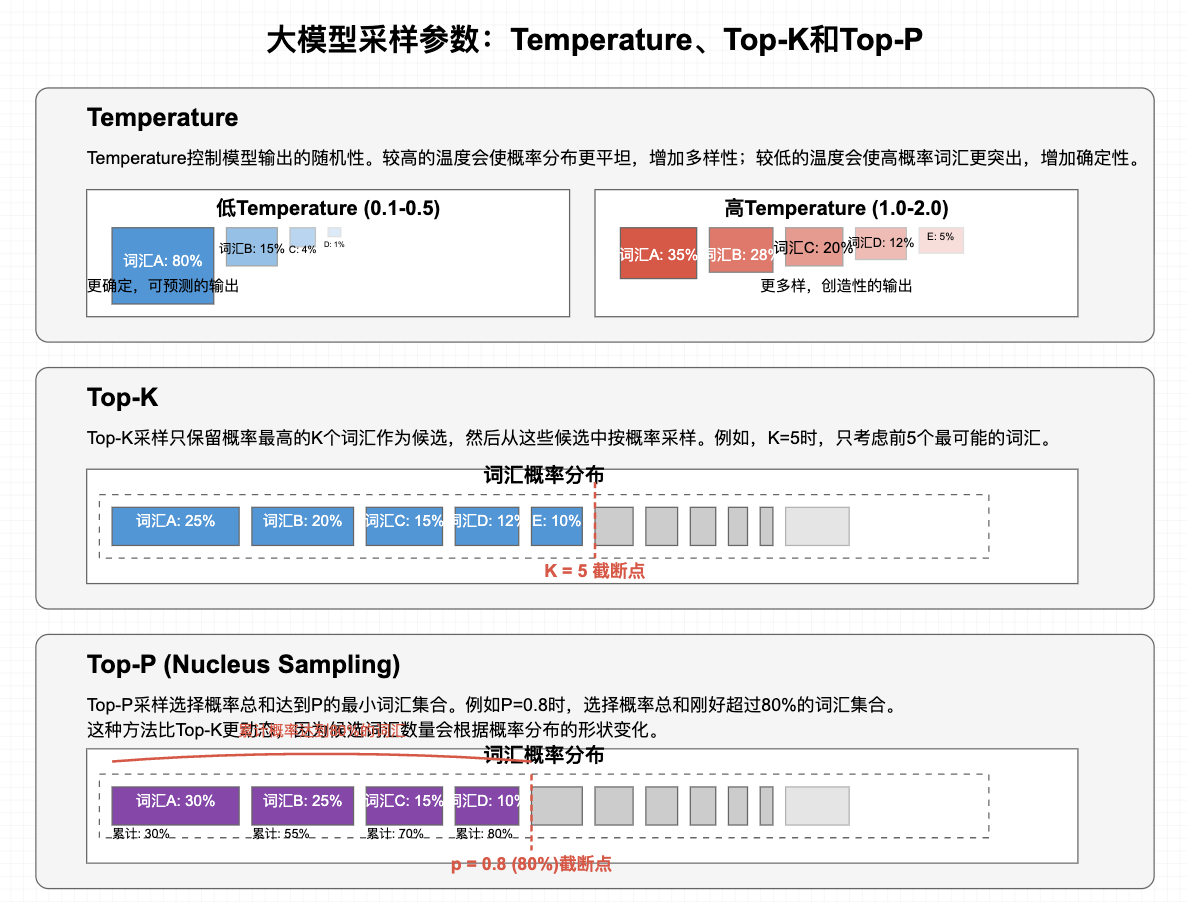

# 3.结构化输出

In [ ]:
from pydantic import BaseModel
from openai import OpenAI

client = OpenAI(api_key='', base_url='https://dashscope.aliyuncs.com/compatible-mode/v1')

class CalendarEvent(BaseModel):
    name: str
    date: str
    participants: list[str]

completion = client.beta.chat.completions.parse(
    model="gpt-4o-2024-08-06",
    messages=[
        {"role": "system", "content": "提取下面的信息."},
        {"role": "user", "content": "小明、小丽和我2025年1月1日去深圳玩"},
    ],
    response_format=CalendarEvent,
)

event = completion.choices[0].message.parsed
print(event)

name='Trip to Shenzhen' date='2025-01-01' participants=['小明', '小丽', '我']


In [46]:
from typing import List, Optional, Union
from pydantic import BaseModel, Field
# 改用基本类型，不使用特殊类型如UUID、EmailStr等

class Address(BaseModel):
    street: str = Field(description="街道地址")
    city: str = Field(description="城市名称")
    postal_code: str = Field(description="邮政编码")
    country: str = Field(description="国家名称")

class UserProfile(BaseModel):
    # 使用字符串而非UUID
    id: str = Field(description="用户唯一标识符")
    
    # 基本类型
    username: str = Field(description="用户名")
    email: str = Field(description="用户邮箱地址")
    password: str = Field(description="用户密码")
    
    # 可选字段
    full_name: Optional[str] = Field(None, description="用户全名")
    age: Optional[int] = Field(None, description="用户年龄")
    
    # 基本类型字段
    is_active: bool = Field(description="用户是否处于活跃状态")
    created_at: str = Field(description="账户创建时间") # 使用字符串而非datetime
    
    # 角色，使用字符串而非枚举
    role: str = Field(description="用户角色")
    
    # 嵌套模型
    address: Optional[Address] = Field(None, description="用户地址信息")
    
    # 列表类型
    tags: List[str] = Field(description="用户标签列表")
    interests: List[str] = Field(description="用户兴趣爱好")
    
    
    # 简化为单一类型
    verification_code: Optional[str] = Field(None, description="验证码")
    
    # 列表中包含复杂对象
    previous_addresses: Optional[List[Address]] = Field(None, description="用户以前的地址列表")
    
    # URL使用字符串
    website: Optional[str] = Field(None, description="用户个人网站URL")
    
    # 日期使用字符串
    birth_date: Optional[str] = Field(None, description="用户出生日期")

In [50]:
completion = client.beta.chat.completions.parse(
    model="gpt-4o-2024-08-06",
    messages=[
        {"role": "system", "content": "提取下面的信息.用中文输出"},
        {"role": "user", "content": '''
        根据用户资料分析，李明（johndoe）是一位30岁的资深Python开发者，他于2023年12月15日加入我们的平台。作为编辑角色，他负责技术内容的审核和更新。个人标签包括"开发者"和"Python爱好者"，主要兴趣集中在人工智能和数据分析领域。

李明的联系方式为john@example.com，他拥有个人网站https://john-portfolio.dev。他目前居住在上海市浦东新区张江高科技园区创新路88号，邮编200120。系统记录显示他曾居住在北京市海淀区中关村软件园。

账户状态显示为活跃，最近一次登录是在昨天下午。在账户设置中，他选择了深色模式界面并开启了双因素认证功能。如需进一步协助，我们可以通过他提供的信息联系他
'''},
    ],
    response_format=UserProfile,
)

event1 = completion.choices[0].message.parsed
print(event1)

id='johndoe' username='johndoe' email='john@example.com' password='*' full_name='李明' age=30 is_active=True created_at='2023-12-15' role='编辑' address=Address(street='创新路88号', city='上海市', postal_code='200120', country='中国') tags=['开发者', 'Python爱好者'] interests=['人工智能', '数据分析'] verification_code=None previous_addresses=[Address(street='软件园', city='北京市', postal_code='*', country='中国')] website='https://john-portfolio.dev' birth_date=None


In [ ]:
import json
from openai import OpenAI

client = OpenAI(
    api_key="",
    base_url="https://api.deepseek.com",
)

system_prompt = """
The user will provide some exam text. Please parse the "question" and "answer" and output them in JSON format. 

EXAMPLE INPUT: 
Which is the highest mountain in the world? Mount Everest.

EXAMPLE JSON OUTPUT:
{
    "question": "Which is the highest mountain in the world?",
    "answer": "Mount Everest"
}
"""

user_prompt = "Which is the longest river in the world? The Nile River."

messages = [{"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}]

response = client.chat.completions.create(
    model="deepseek-chat",
    messages=messages,
    response_format={
        'type': 'json_object'
    }
)

print(json.loads(response.choices[0].message.content))

{'question': 'Which is the longest river in the world?', 'answer': 'The Nile River'}


### 一般使用方式，定义一个函数

In [ ]:
def llm_chat(user_prompt):
    client = OpenAI(
    api_key="",
    base_url="https://api.deepseek.com",
    )
    
    system_prompt = """
    The user will provide some exam text. Please parse the "question" and "answer" and output them in JSON format. 
    
    EXAMPLE INPUT: 
    Which is the highest mountain in the world? Mount Everest.
    
    EXAMPLE JSON OUTPUT:
    {
        "question": "Which is the highest mountain in the world?",
        "answer": "Mount Everest"
    }
    """
    
    
    messages = [{"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}]
    
    response = client.chat.completions.create(
        model="deepseek-chat",
        messages=messages,
        response_format={
            'type': 'json_object'
        }
    )
    
    return json.loads(response.choices[0].message.content)

In [57]:
user_prompt = "Which is the longest river in the world? The Nile River."

In [59]:
output=llm_chat(user_prompt)

In [65]:
print(output)
print(output["question"])

{'question': 'Which is the longest river in the world?', 'answer': 'The Nile River'}
Which is the longest river in the world?


In [63]:
type(output)

dict

# 4. 万能却又不万能的提示词模版

<font color="red">为什么要写提示词？</font>

- 是为了在你产品的场景里面解决几乎用户所有的问题，用户用你的产品不可能一直和你chat，要达到用户输入一个哪怕模糊的输入，也能得到满意的结果或者进行信息补全

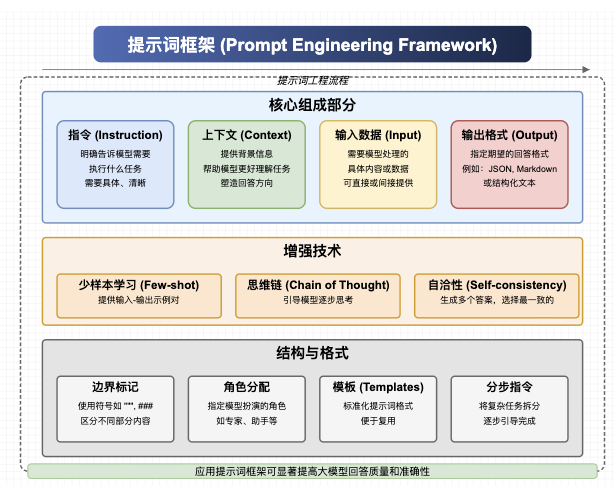

## 4.1 非推理模型

- 角色，背景，目标，约束，工作流，外部文档，输出规则

In [80]:
prompt='''
# 任务指令
作为一位[专业角色]，请[执行具体任务]。

# 背景上下文
以下是关于[主题/问题]的背景信息：
- [相关信息点1]
- [相关信息点2]
- [相关信息点3]

# 输入数据
"""
[这里放置需要处理的文本/数据/内容]
"""

# 要求与约束
请遵循以下要求：
1. [要求1，例如：分析的深度]
2. [要求2，例如：考虑特定因素]
3. [要求3，例如：使用特定方法]
4. [限制/约束，例如：回答字数限制]

# 输出格式
请按照以下结构提供您的回答：

## [第一部分标题]
[对第一部分内容的描述要求]

## [第二部分标题]
[对第二部分内容的描述要求]

## [第三部分标题]
[对第三部分内容的描述要求]

# 示例（少样本学习）
输入：[示例输入]
输出：[示例期望输出]

# 思考过程
在提供最终答案前，请先：
1. [思考步骤1]
2. [思考步骤2]
3. [思考步骤3]
4. 对您的回答进行自我评估和审查

# 按照一下JSON格式进行输出
{
"思考过程"：
"输出结果"：
}
'''



## 1. 少样本学习 (Few-shot)

**原理**：通过提供几个输入-输出示例对，帮助模型理解任务期望。

**示例**：文本情感分析任务

```
请分析以下文本的情感倾向，判断为"正面"、"负面"或"中性"。

示例1:
文本: "这家餐厅的服务太差了，等了一个小时才上菜，而且味道也不怎么样。"
情感: 负面

示例2:
文本: "新手机运行速度非常快，摄像功能也很强大，非常满意这次购买。"
情感: 正面

示例3:
文本: "今天天气多云，温度适中，预计明天可能有小雨。"
情感: 中性

现在请分析:
文本: "虽然价格有点贵，但考虑到产品质量和售后服务，我认为还是很值得的。"
情感:
```

通过提供这些示例，模型学会了如何判断不同类型文本的情感倾向，然后应用到新文本上。

## 2. 思维链 (Chain of Thought)

**原理**：引导模型像人类一样逐步思考问题，展示推理过程，而不是直接给出答案。

**示例**：解决数学应用题

```
问题: 一个农场有27只动物，包括鸡和兔子。如果总共有74条腿，那么农场里有多少只鸡和多少只兔子？

思考过程:
1. 我们有27只动物总数，包括鸡和兔子
2. 设鸡的数量为x，兔子的数量为y
3. 那么我们知道 x + y = 27
4. 每只鸡有2条腿，每只兔子有4条腿
5. 所以腿的总数为: 2x + 4y = 74
6. 从第一个方程，我们可以得到 x = 27 - y
7. 将其代入第二个方程: 2(27 - y) + 4y = 74
8. 展开: 54 - 2y + 4y = 74
9. 简化: 54 + 2y = 74
10. 求解y: 2y = 20, 所以 y = 10
11. 因此 x = 27 - 10 = 17

答案: 农场里有17只鸡和10只兔子。
```

这种方法让模型展示其思考过程，提高了解决复杂问题的准确性。

## 3. 自洽性 (Self-consistency)

**原理**：让模型生成多个解决方案，然后选择最一致或最常见的答案，提高可靠性。

**示例**：解决模糊问题

```
问题: 杯子掉在地上会发生什么？

请从不同角度思考5种可能的回答，然后给出最合理的结论。

思路1: 如果杯子是玻璃制的，掉在硬地面上很可能会碎。这取决于掉落高度、杯子材质和地面硬度。
思路2: 如果杯子是塑料或金属制的，可能会弹跳几下但不会碎，只是可能会有凹痕或划痕。
思路3: 杯子里的液体会洒出来，形成一滩水渍或其他液体痕迹，可能需要清理。
思路4: 如果杯子掉落时是空的且材质结实，可能除了发出声音外没有明显后果。
思路5: 杯子掉落可能会惊动周围的人或动物，引起注意或反应。

综合分析:
考虑到各种可能性，最一致的结论是：杯子掉在地上的具体后果取决于杯子的材质、内容物、掉落高度和地面类型。最常见的情况是杯子内的液体会洒出，如果是玻璃杯则有较高概率破碎，而塑料或金属杯则可能只会产生噪音和轻微损伤。
```

这种方法通过多角度思考同一问题，汇总出最一致或最合理的答案，降低了随机性错误的可能性。


- **提示词不是一成不变的万能方案，而是一个需要不断优化的迭代过程。应基于bad case分析不断修正指令，使其在特定场景下，无论输入条件如何变化，都能稳定地达到目标结果或提高准确度。这一过程不仅依赖于对错误样例的深入理解，还需要持续调整和测试，以确保模型输出的有效性和鲁棒性。**

## 4.2 推理模型

![](./reasoning-prompt-framework.svg)